Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

Inicializaciones

In [1]:
#Dimensiones de la imagen a crear
ancho = 300
alto = 200

Imagen en grises

In [4]:
#Crea una imagen de un único plano
# Al ser un único plano, se interpreta como nivel de gris (0 negro, 255 blanco)
gris_img = np.zeros((alto,ancho,1), dtype = np.uint8)
#Muestra dimensiones de la imagen creada
print(gris_img.shape)

(200, 300, 1)


Muestra imagen con imshow (OpenCV). Observa que se muestra en ventana independiente

In [5]:
#Muestra la imagen (negra al inicializarse a 0) con las utilidades de OpenCV en una ventana independiente
cv2.imshow('Imagen', gris_img)

cv2.waitKey(-1) # Se detiene hasta pulsar tecla (>0 milisegundos)
cv2.destroyAllWindows() # Destruye todas las ventanas

Muestra imagen con matplotlib

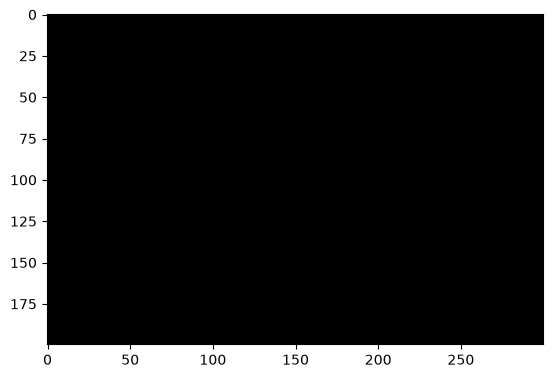

In [5]:
#Muestra la imagen con matplotlib, aparece integrada en el cuaderno
#Es necesario especificar que el mapa de color usado es de grises
plt.imshow(gris_img, cmap='gray') #default: 'viridis'
#plt.imshow(gris_img) #Sin escoger el mapa de colores
plt.show()

#replicar una imagen de gris creando una imagen gris pero con tres planos (RGB)
#img2 = cv2.merge((gris_img,gris_img,gris_img))
#plt.imshow(img2)
#plt.show()

Imagen con tono de gris aleatorio

(200, 300, 1)


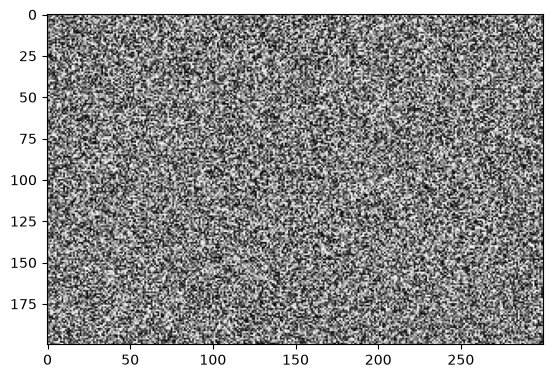

In [6]:
#Crea imagen con un único plano (gris)
gris_img = np.random.randint(255, size=(alto,ancho, 1))
#Muestra dimensiones
print(gris_img.shape)
#Visualiza
plt.imshow(gris_img, cmap='gray') #Visualiza con mapa de color gris
plt.show()

Asignamos valor a los píxeles de una zona concreta

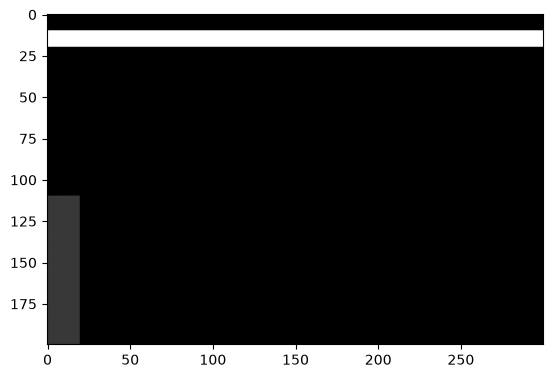

In [29]:
gris_img = np.zeros((alto,ancho,1), dtype = np.uint8)
#Modifica un par de zonas rectangulares de la imagen
gris_img[10:20,0:ancho,0] = 128 #tercer índice especifica un canal (0-2)
gris_img[110:220,0:20,0] = 28 #
#gris_img[50:70,40:60] = 255 #realmente no es necesario especificar el plano con un único plano

#matplotlib aplica normalización entre lso valores máximo y mínimo de la imagen
#gris_img[:,:,:] = 255 #se verá negra a menos que se especifiquen vmin y vmax

#Muestra la imagen con matplotlib
#Al ser un plano, al visualizar, recordar especificar que el mapa de color usado es de grises
plt.imshow(gris_img, cmap='gray') #Prueba sin especificar el mapa de color
#plt.imshow(gris_img, cmap='gray',vmin=0, vmax=255) #evita el efecto de la normalización de matplotlib
plt.show()

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

### Resolución de la tarea 1 (tablero de ajedrez)

En este caso he optado por crear variables que representen en que coordenada empieza cada cuadrado, tanto en filas como en columnas (los cuadrados serán de 100x100) y otra variable para almacenar si la fila que pintamos es par o impar

Se recorren filas y columnas a través 2 bucles, en los que se utiliza la variable numero_fila para determinar donde se empieza a pintar la fila, de forma que se puede empezar en la posición 0 en las filas impares y en la posición 100 en las pares, para lograr el efecto de un tablero de ajedrez

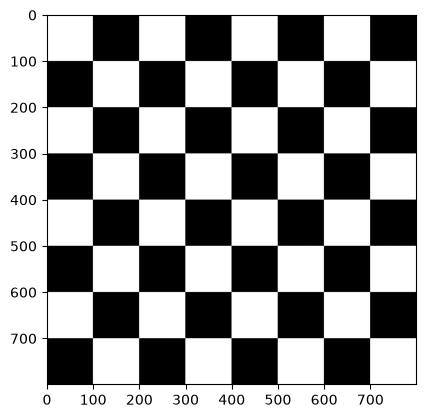

In [37]:
tablero_ajedrez = np.zeros((800, 800, 1), dtype = np.uint8)

# recorreremos el tablero por filas y columnas, haciendo cuadrados de 100x100
inicio_fila = 0
final_fila = 100

inicio_columna = 0
final_columna = 100

numero_fila = 1

while inicio_fila <= 800:

    while inicio_columna <= 800:
        tablero_ajedrez[inicio_fila:final_fila,inicio_columna:final_columna,0] = 128 
        inicio_columna += 200
        final_columna += 200

    inicio_fila += 100
    final_fila += 100
    numero_fila += 1

    if numero_fila % 2 == 0:
        inicio_columna = 100
        final_columna = 200
    else:
        inicio_columna = 0
        final_columna = 100

plt.imshow(tablero_ajedrez, cmap='gray')
plt.show()

Una vez terminado, le he pedido a GPT-5.6 Luna que resuelva la tarea con la única instrucción de que la resuelva de la manera más eficiente posible, y ha dado la siguiente respuesta:

"La forma más eficiente es generarlo de manera vectorizada con NumPy, sin recorrer píxel a píxel ni usar bucles. La paridad de la fila y la columna determina si cada casilla es negra o blanca"

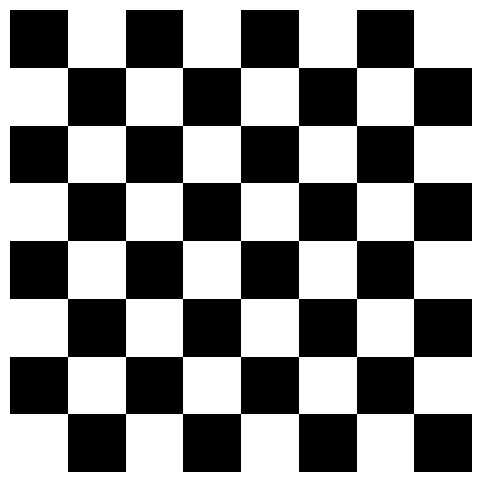

In [7]:
# Dimensiones del tablero
alto = 800
ancho = 800
lado_casilla = 100

# Número de casilla correspondiente a cada fila y columna
filas = np.arange(alto) // lado_casilla
columnas = np.arange(ancho) // lado_casilla

# Alternancia de colores mediante la paridad fila + columna
tablero_ajedrez = (
    (filas[:, np.newaxis] + columnas[np.newaxis, :]) % 2 * 255
).astype(np.uint8)

# Visualización
plt.figure(figsize=(6, 6))
plt.imshow(
    tablero_ajedrez,
    cmap='gray',
    vmin=0,
    vmax=255,
    interpolation='nearest'
)
plt.axis('off')
plt.show()

A diferencia de mí, GTP-5.6 Luna planteó la solución al problema utilizando directamente utilidades de NumPy, almacenó las variables de alto y ancho y de lado de cada cuadrado

Imagen en color

(200, 300, 3)


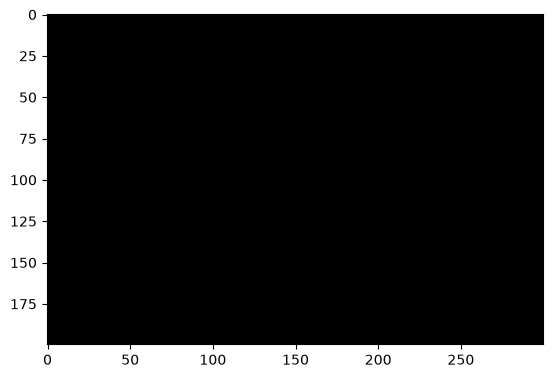

In [14]:
#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)
#Dimensiones
print(color_img.shape)
#Visualiza con matplotlib (sin especificar el mapa de color gris)
plt.imshow(color_img) 
plt.show()


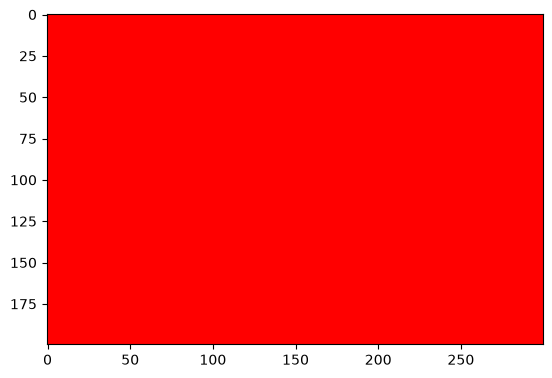

In [17]:
#Modifica el primer plano de color (Rojo, ya que es RGB)
color_img[:,:,0] = 255 
#color_img[:,:,1] = 200 #Prueba otras combinaciones
#color_img[:,:,2] = 255 
plt.imshow(color_img) 
plt.show()

Funciones de dibujo.
OpenCV dispone de funciones específicas para dibujar formas básicas (más información https://docs.opencv.org/4.x/dc/da5/tutorial_py_drawing_functions.html )

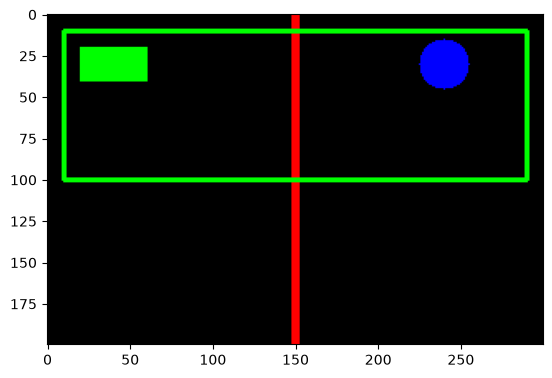

True

In [18]:
#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)

#Línea roja vertical de grosor 3
cv2.line(color_img,(int(ancho/2),0),(int(ancho/2),alto),(255,0,0),3)
#Rectángulo con grosor 2
cv2.rectangle(color_img,(10,10),(ancho-10,int(alto/2)),(0,255,0),2)
#Rectángulo relleno
cv2.rectangle(color_img,(20,20),(60,40),(0,255,0),-1)
#Círculo de radio 15 relleno
cv2.circle(color_img,(ancho-60,30), 15, (0,0,255), -1)
#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img) 
plt.show()

#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img)

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

### Resolución de la tarea 2 (imagen estilo Mondrian)

Para esta tarea y observando la imagen del enlace de la tarea, primero vamos a crear un lienzo blanco, sobre él dibujaremos líneas negras y por último usaremos rectángulos y cuadrados para colorear el interior de las formas que dejen las líneas negras

Nota: se tiene en cuenta que el grosor por linea es de 10

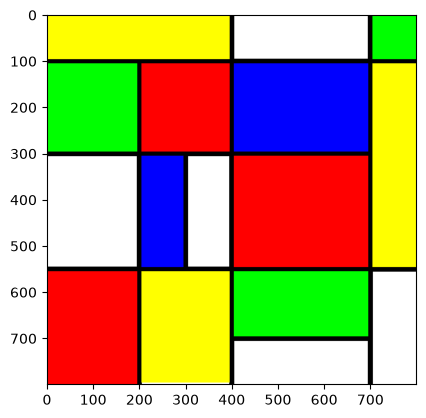

In [19]:
mondrian = np.zeros((alto,ancho,3), dtype = np.uint8)
mondrian[:,:,0] = 255
mondrian[:,:,1] = 255
mondrian[:,:,2] = 255

cv2.line(mondrian,(400, 0),(400,800),(0,0,0),10)
cv2.line(mondrian,(700, 0),(700,800),(0,0,0),10)

cv2.line(mondrian,(0, 100),(800,100),(0,0,0),10)
cv2.line(mondrian,(0, 550),(800,550),(0,0,0),10)

cv2.line(mondrian,(0, 300),(700,300),(0,0,0),10)
cv2.line(mondrian,(200, 100),(200,800),(0,0,0),10)
cv2.line(mondrian,(400, 700),(700,700),(0,0,0),10)
cv2.line(mondrian,(300, 300),(300,550),(0,0,0),10)

cv2.rectangle(mondrian,(0,105),(195,295),(0,255,0),-1)
cv2.rectangle(mondrian,(205,105),(395,295),(255,0,0),-1)
cv2.rectangle(mondrian,(205,305),(295,545),(0,0,255),-1)
cv2.rectangle(mondrian,(405,105),(695,295),(0,0,255),-1)
cv2.rectangle(mondrian,(405,305),(695,545),(255,0,0),-1)
cv2.rectangle(mondrian,(405,555),(695,695),(0,255,0),-1)
cv2.rectangle(mondrian,(205,555),(395,795),(255,255,0),-1)
cv2.rectangle(mondrian,(0,0),(395,95),(255,255,0),-1)
cv2.rectangle(mondrian,(705,105),(800,545),(255,255,0),-1)
cv2.rectangle(mondrian,(705,0),(800,95),(0,255,0),-1)
cv2.rectangle(mondrian,(0,555),(195,800),(255,0,0),-1)

plt.imshow(mondrian) 
plt.show()

Abrir imagen almacenada en disco

(1200, 1180, 3)


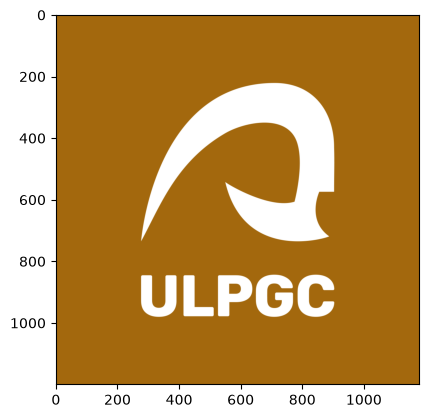

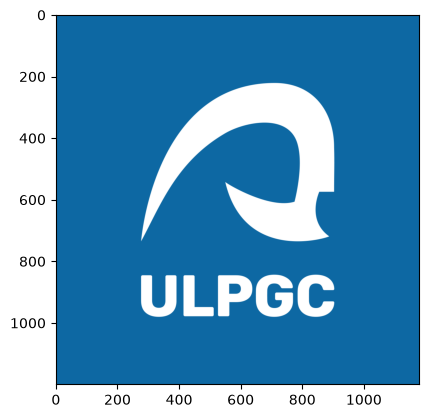

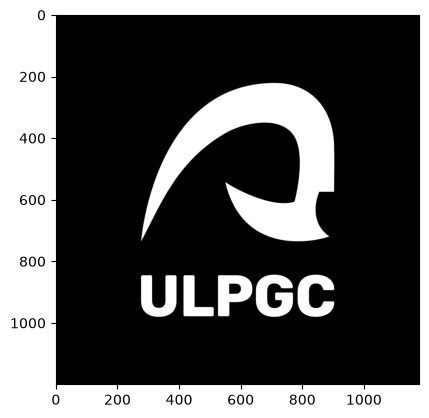

In [20]:
#Carga imagen desde disco
img = cv2.imread('logo_ulpgc_vertical_acronimo_mancheta_azul.png') 
#Dimensiones
print(img.shape)
#Muestra
plt.imshow(img) 
plt.show()

#OpenCV lee las imágenes de disco en formato BGR, por lo que convertimos para visualizr RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) 
plt.show()

#Fuerza lectura en grises
img = cv2.imread('logo_ulpgc_vertical_acronimo_mancheta_azul.png', cv2.IMREAD_GRAYSCALE) 
plt.imshow(img, cmap='gray') 
plt.show()


Abre un archivo de vídeo

In [2]:
# Abre vídeo
vid = cv2.VideoCapture('VermeerFun.mp4') 
  
# En caso de estar abierto
if vid.isOpened():
    while(True):      
        # fotograma a fotograma
        ret, frame = vid.read()

        # Hay nuevo fotograma
        if ret:  
            # Muestra fotograma
            cv2.imshow('Vid', frame)
        
        # Detenemos pulsado ESC
        if cv2.waitKey(20) == 27:
            break
    
    # Libera el objeto de captura
    vid.release()
    # Destruye ventanas
    cv2.destroyAllWindows()

Muestra entrada de la cámara

In [3]:
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
  
    # Hay nuevo fotograma
    if ret:  
        # Muestra fotograma
        cv2.imshow('Vid', frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Separa los tres planos de la imagen captada por la webcam y muestra en horizontal

In [4]:
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        #Separamos canales
        b = frame[:,:,0]
        g = frame[:,:,1]
        r = frame[:,:,2]
        #Dimensiones imagen de entrada
        h, w, c = frame.shape

        #Concateamos en horizontal los tres planos del fotograma
        collage = np.hstack((r, g, b))
    
        # Muestra fotograma redimensionando a la mitad para que quepa en pantalla
        cv2.imshow('RGB', cv2.resize(collage, (int(w*1.5),int(h/2)),cv2.INTER_NEAREST))
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Evento de ratón para mostrar el valor RGB del píxel

In [5]:
# Función que trata eventos de ratón 
def mouse_events(event, x, y, flags, params):
    global px, py, R, G, B
    px = -1
    # Movimiento del puntero     
    if event==cv2.EVENT_MOUSEMOVE:
        #Valores del píxel, desde la webcam no es BGR
        B = frame[y, x, 0]
        G = frame[y, x, 1]
        R = frame[y, x, 2]  
        # Almacena valores del evento
        px = x
        py = y

     
  

In [6]:
vid = cv2.VideoCapture(0)

# Tipografía para mostrar texto
font = cv2.FONT_HERSHEY_SIMPLEX
  
lanzado = 0 #bandera para primer fotograma
px = -1
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret: 
        # Activa el manejador en el primer fotograma
        if lanzado == 0:
            # Muestra fotograma
            cv2.imshow('Cam', frame)   
            # Define el nombre del manejador del evento
            cv2.setMouseCallback('Cam', mouse_events)
            lanzado = 1
            
        # Muestra valores RGB intentando centrar en el puntero
        if px > -1:
            cv2.putText(frame, '{}'.format(R), (px-45,py-5), font, 0.5, (0, 0, 255), 1)
            cv2.putText(frame, '     {}'.format(G), (px-54,py-5), font, 0.5, (0, 255, 0), 1)
            cv2.putText(frame, '         {}'.format(B), (px-54,py-5), font, 0.5, (255, 0, 0), 1)
            
        cv2.imshow('Cam', frame)   
        
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


### Resolución tarea 3 (pintar círculos en el píxel más claro y más oscuro)

Para ello vamos a partir del código básico en el que mostramos la cámara y vamos a buscar el píxel de mayor intensidad con el de menor intensidad usando la función de cv2 minMaxLoc, la cual devuelve la intensidad del pixel más claro y más oscuro, y una tupla para cada pixel con su posición (x,y)

Previamente debemos pasar el frame a escala de grises para determinar el pixel mas claro y el más oscuro en base a su brillo

In [ ]:
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
  
    # Hay nuevo fotograma
    if ret:  
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        min_val, max_val, min_coord, max_coord = cv2.minMaxLoc(gray)

        # pixel más oscuro de color rojo
        cv2.circle(frame, (min_coord[0], min_coord[1]), 10, (0, 0, 255));

        # pixel más claro de color amarillo
        cv2.circle(frame, (max_coord[0], max_coord[1]), 10, (0, 255, 255));

        # Muestra fotograma
        cv2.imshow('Vid', frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Si ejecutamos el codigo anterior, vemos que si hay varios elementos de una intensidad similar, el círculo que le corresponde a dicha intensidad "salta" de un lado para otro dentro de los píxeles que tienen dicha intensidad, por lo que parece que funciona a saltos

Pop art
Salida de la webcam "inspirada" en Andy Warhol (Marilyn, https://temasycomentariosartepaeg.blogspot.com/p/autor-andy-warhol-1928-1987-titulo.html)

In [35]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) #En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 2x original
collage = np.zeros((h*2,w*2,3), dtype = np.uint8)
tl = collage[0:h,0:w]
tr = collage[0:h,w:w+w]
bl = collage[h:h+h,0:w]
br = collage[h:h+h,w:w+w]

while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Separamos canales
        r = frame[:,:,2]
        g = frame[:,:,1]
        b = frame[:,:,0]

        #Jugamos con los valores de los planos
        tl[:,:,0] = b
        tl[:,:,1] = g
        tl[:,:,2] = r

        tr[:,:,0] = 255 - r
        tr[:,:,1] = g
        tr[:,:,2] = b
        
        bl[:,:,0] = r
        bl[:,:,1] = 255 - b
        bl[:,:,2] = g

        br[:,:,0] = b
        br[:,:,1] = g
        br[:,:,2] = 255 - r
    
        # Muestra composición
        cv2.imshow('Cam', collage)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Transformando la imagen capturada en una colección de círculos, cuyo radio depende de la intensidad promedio de la zona

In [8]:
vid = cv2.VideoCapture(0)

# Se define el número de celdas
ncells = 10
off = int(ncells/2)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        #Dimensiones originales
        h, w, c = frame.shape
        #Redimensiono teniendo en cuenta ncells
        down_frame = cv2.resize(frame, (int(w/ncells),int(h/ncells)),cv2.INTER_NEAREST)
        #Dimensiones reducidas
        h2, w2, c2 = down_frame.shape

        #Separamos canales
        r = down_frame[:,:,0]
        g = down_frame[:,:,1]
        b = down_frame[:,:,2]

        # Creamos imagen negra
        gris_up_frame = np.zeros((h2*ncells,w2*ncells,1), dtype = np.uint8)

        # recorre valores de la imagen reducida
        for y in range(0,h2):
            for x in range(0,w2):
                # La suma de los valores RGB define el radio del círculo
                rad = int ( (r[y,x] + g[y,x] + b[y,x])/(ncells*3*2))
                cv2.circle(gris_up_frame,(x*ncells+off, y*ncells + off), rad, (255,255,255), -1)

    
        # Muestra fotograma resultante
        cv2.imshow('Cam', gris_up_frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

C:\Users\kikoa\AppData\Local\Temp\ipykernel_32480\531065525.py:31: RuntimeWarning: overflow encountered in scalar add
  rad = int ( (r[y,x] + g[y,x] + b[y,x])/(ncells*3*2))


TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

### Resolución tarea 4 (pop art personalizado)

Para esta tarea se ha decidido imitar la composición del siguiente pop art: https://es.wikipedia.org/wiki/Arte_pop#/media/Archivo:David_Bowie-Gil_Zetbase.jpg

De forma que es necesario primero crear un collage de 3x3 y posteriormente ir añadiendo los planos correspondientes por fila y columna, para luego jugar con la composición de colores de cada cuadrado dentro del collage

In [36]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)

vid.set(cv2.CAP_PROP_FRAME_WIDTH, w)
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 3x3 original
collage = np.zeros((h*3,w*3,3), dtype = np.uint8)

aa = collage[0:h,     0:w]
ab = collage[0:h,     w:w*2]
ac = collage[0:h,     w*2:3*w]

ba = collage[h:h*2,   0:w]
bb = collage[h:h*2,   w:w*2]
bc = collage[h:h*2,   w*2:w*3]

ca = collage[h*2:h*3, 0:w]
cb = collage[h*2:h*3, w:w*2]
cc = collage[h*2:h*3, w*2:w*3]


while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Separamos canales
        r = frame[:,:,2]
        g = frame[:,:,1]
        b = frame[:,:,0]

        #Jugamos con los valores de los planos
        aa[:,:,0] = 255 - b
        aa[:,:,1] = g
        aa[:,:,2] = r

        ab[:,:,0] = b
        ab[:,:,1] = 255 - g
        ab[:,:,2] = r

        ac[:,:,0] = b
        ac[:,:,1] = g
        ac[:,:,2] = 255 - r

        ba[:,:,0] = b // 2
        ba[:,:,1] = 255 - g
        ba[:,:,2] = r

        bb[:,:,0] = b
        bb[:,:,1] = g // 2
        bb[:,:,2] = 255 - r

        bc[:,:,0] = 255 - b
        bc[:,:,1] = g
        bc[:,:,2] = r // 2

        ca[:,:,0] = 128 - b // 2
        ca[:,:,1] = 255 - g
        ca[:,:,2] = r

        cb[:,:,0] = b
        cb[:,:,1] = 128 - g // 2
        cb[:,:,2] = 255 - r

        cc[:,:,0] = 255 - b
        cc[:,:,1] = g
        cc[:,:,2] = 128 - r // 2


        # Muestra composición
        cv2.imshow('Cam', collage)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()